In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
df = pd.read_csv("crop_yield.csv")
print(df.head())

  Region Soil_Type     Crop  Rainfall_mm  Temperature_Celsius  \
0   West     Sandy   Cotton   897.077239            27.676966   
1  South      Clay     Rice   992.673282            18.026142   
2  North      Loam   Barley   147.998025            29.794042   
3  North     Sandy  Soybean   986.866331            16.644190   
4  South      Silt    Wheat   730.379174            31.620687   

   Fertilizer_Used  Irrigation_Used Weather_Condition  Days_to_Harvest  \
0            False             True            Cloudy              122   
1             True             True             Rainy              140   
2            False            False             Sunny              106   
3            False             True             Rainy              146   
4             True             True            Cloudy              110   

   Yield_tons_per_hectare  
0                6.555816  
1                8.527341  
2                1.127443  
3                6.517573  
4                7.24825

In [3]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Region                  1000000 non-null  object 
 1   Soil_Type               1000000 non-null  object 
 2   Crop                    1000000 non-null  object 
 3   Rainfall_mm             1000000 non-null  float64
 4   Temperature_Celsius     1000000 non-null  float64
 5   Fertilizer_Used         1000000 non-null  bool   
 6   Irrigation_Used         1000000 non-null  bool   
 7   Weather_Condition       1000000 non-null  object 
 8   Days_to_Harvest         1000000 non-null  int64  
 9   Yield_tons_per_hectare  1000000 non-null  float64
dtypes: bool(2), float64(3), int64(1), object(4)
memory usage: 62.9+ MB
None
Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_

In [4]:
df = df.dropna()

In [5]:
X=df.drop('Yield_tons_per_hectare', axis=1)
y = df['Yield_tons_per_hectare']

In [6]:
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

In [8]:
rf_model = RandomForestRegressor(
    n_estimators=100,      # number of trees
    max_depth=10,          # control tree depth
    random_state=42
)

In [9]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', rf_model)
])

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Region', 'Soil_Type', 'Crop', 'Weather_Condition'], dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used',
       'Irrigation_Used', 'Days_to_Harvest'],
      dtype='object'))])),
                ('regressor',
                 RandomForestRegressor(max_depth=10, random_state=42))])

In [12]:
y_pred = model.predict(X_test)

In [13]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 0.40023177714310454
R2 Score: 0.9127172053888111


In [14]:
# Get feature names after encoding
encoded_cols = model.named_steps['preprocessor']\
                   .transformers_[0][1]\
                   .get_feature_names_out(cat_cols)

all_features = list(encoded_cols) + list(num_cols)

# Feature importance
importances = model.named_steps['regressor'].feature_importances_

feat_imp = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp.head(10))

                Feature  Importance
19          Rainfall_mm    0.640636
21      Fertilizer_Used    0.214184
22      Irrigation_Used    0.136552
20  Temperature_Celsius    0.008377
23      Days_to_Harvest    0.000128
7       Soil_Type_Peaty    0.000008
11          Crop_Cotton    0.000007
15           Crop_Wheat    0.000007
2          Region_South    0.000007
12           Crop_Maize    0.000007


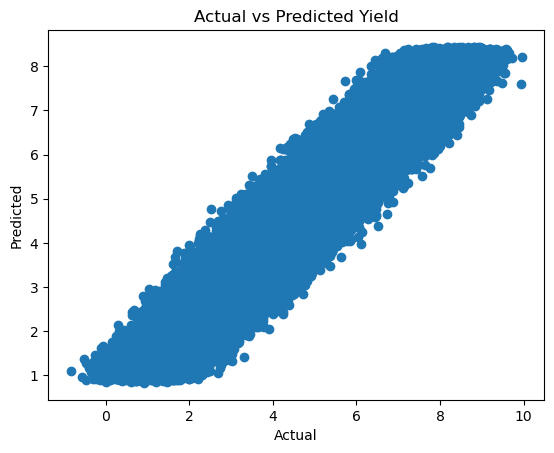

In [15]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Yield")
plt.show()

In [16]:
import pandas as pd

sample = pd.DataFrame({
    'Region': ['South'],
    'Soil_Type': ['Clay'],
    'Crop': ['Rice'],
    'Weather_Condition': ['Sunny'],
    'Rainfall_mm': [1300],
    'Temperature_Celsius': [29],
    'Fertilizer_Used': [200],
    'Irrigation_Used': [1],
    'Days_to_Harvest': [120]
})

prediction = model.predict(sample)

print("Predicted Yield:", prediction[0])

Predicted Yield: 8.2633397085515


In [17]:
joblib.dump(model, "yield_model.pkl")
print("Model saved as yield_model.pkl")

Model saved as yield_model.pkl
